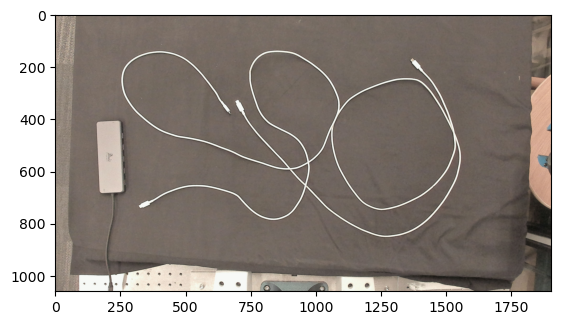

In [1]:
from decluttering.scripts.brio.brio_sensor import BRIOSensor
import numpy as np
import cv2
import matplotlib.pyplot as plt

cam = BRIOSensor(0)
dim = (1060, 1904, 3)
img = cam.read()
img = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2)) # dim

plt.imshow(img)

In [2]:
from decluttering.data.utils.endpoint_detector_dataloader import EndpointDataloader

endpoint_model = EndpointDataloader()
endpoints = endpoint_model.predict(img)['endpoints']


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride
/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Time taken for analytic tracer: 0.13011813163757324
Beginning trace with 4 start points
Elapsed time for tracing:  0.7615878582000732
Time taken for analytic tracer: 0.12651467323303223
Beginning trace with 4 start points
Elapsed time for tracing:  1.5284645557403564
Time taken for analytic tracer: 0.1262376308441162
Beginning trace with 4 start points
Elapsed time for tracing:  1.4800128936767578
Time taken for analytic tracer: 0.13195538520812988
Beginning trace with 4 start points
Elapsed time for tracing:  1.7090449333190918
elapsed time: 7.557202577590942


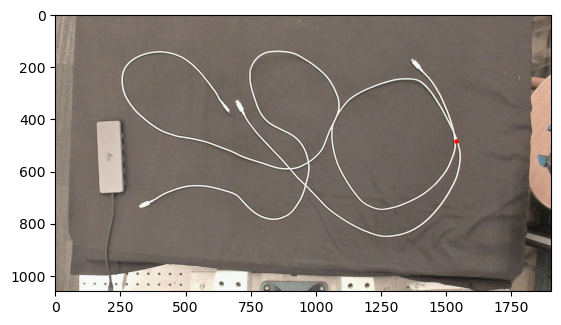

In [4]:
from decluttering.src.divergence_utils.divergence import get_all_div_points
import time

start_time = time.time()
output = get_all_div_points(img, endpoints)
print(f'elapsed time: {time.time()-start_time}')

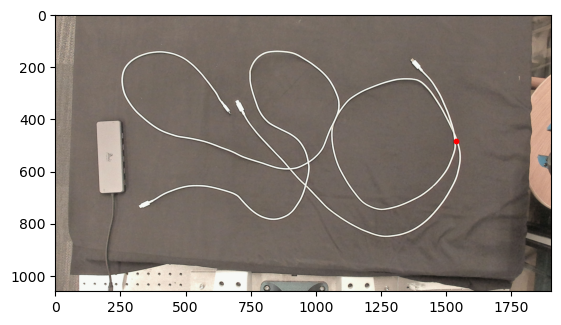

In [6]:
plt.imshow(img)
plt.scatter(output['div_points'][:, 0], output['div_points'][:, 1], c='r', s=10)

In [ ]:
from decluttering.src.motion_jacobi import get_poi_and_vec_for_push, perform_push_through, get_push_coords

get_push_coords(output['div_points'], img, output['trace_list'], output['start_idx'], output['end_idx'])
